# Using libraries in python

In [ ]:
class CashFlows:
    def __init__(self):
        self.cash_flows = {} # an attribute to store maturities mapped to amounts
    
    def add_cash_flow(self, maturity, amount):
        """Add a cash flow to the cash flow list."""
        self.cash_flows[maturity] = amount
    
    def get_cash_flow(self, maturity):
        """Get the cash flow amount for a specific maturity."""
        return self.cash_flows.get(maturity)
    
    def get_maturities(self):
        """Return a list of all maturities."""
        return list(self.cash_flows.keys())
    
    def get_amounts(self):
        """Return a list of all cash flow amounts."""
        return list(self.cash_flows.values())
    
    def get_cash_flows(self):
        """Return all cash flows as (maturity, amount) pairs."""
        return self.cash_flows
    
    # Create a CashFlows object
my_cash_flows = CashFlows()

# Add some cash flows (e.g., initial investment and future payments)
my_cash_flows.add_cash_flow(0, -100)      # Pay $100 today
my_cash_flows.add_cash_flow(0.5, 5)       # Receive $5 in 6 months
my_cash_flows.add_cash_flow(1.0, 105)     # Receive $105 in 1 year

# Access the data using methods
print("All maturities:", my_cash_flows.get_maturities())
print("All amounts:", my_cash_flows.get_amounts())
print("\nCash flow at time 1.0:", my_cash_flows.get_cash_flow(1.0))
print("\nAll cash flows as pairs:", my_cash_flows.get_cash_flows())

All maturities: [0, 0.5, 1.0]
All amounts: [-100, 5, 105]

Cash flow at time 1.0: 105

All cash flows as pairs: {0: -100, 0.5: 5, 1.0: 105}


# Part 1: Pandas DataFrames

Pandas is a powerful library for data manipulation and analysis in Python. It provides data structures like Series and DataFrame, which are essential for handling structured data.

This notebook provides a comprehensive guide on how to use and manipulate Pandas DataFrames using examples from financial markets. 

## 1. Introduction to Pandas DataFrames

A DataFrame is a two-dimensional, size-mutable, and potentially heterogeneous tabular data structure with labeled axes (rows and columns). It is similar to a spreadsheet or SQL table.

### Importing Pandas
First, we need to import the Pandas library.

In [3]:
import pandas as pd

### Creating a DataFrame
Let's create a DataFrame with some financial market data.

In [4]:
# Creating a DataFrame
data = {
    'Date': pd.date_range(start='2023-01-01', periods=5, freq='D'),
    'AAPL': [150.75, 153.30, 149.50, 155.00, 157.25],
    'GOOGL': [2800.50, 2820.00, 2790.00, 2850.00, 2900.00],
    'MSFT': [299.00, 305.00, 300.00, 310.00, 315.00]
}
df = pd.DataFrame(data)
print(df)

        Date    AAPL   GOOGL   MSFT
0 2023-01-01  150.75  2800.5  299.0
1 2023-01-02  153.30  2820.0  305.0
2 2023-01-03  149.50  2790.0  300.0
3 2023-01-04  155.00  2850.0  310.0
4 2023-01-05  157.25  2900.0  315.0


## 2. Basic DataFrame Operations

### Viewing Data
You can view the first few rows of the DataFrame using the `head()` method and the last few rows using the `tail()` method.

In [5]:
# Viewing the first few rows
print(df.head())

# Viewing the last few rows
print(df.tail())

        Date    AAPL   GOOGL   MSFT
0 2023-01-01  150.75  2800.5  299.0
1 2023-01-02  153.30  2820.0  305.0
2 2023-01-03  149.50  2790.0  300.0
3 2023-01-04  155.00  2850.0  310.0
4 2023-01-05  157.25  2900.0  315.0
        Date    AAPL   GOOGL   MSFT
0 2023-01-01  150.75  2800.5  299.0
1 2023-01-02  153.30  2820.0  305.0
2 2023-01-03  149.50  2790.0  300.0
3 2023-01-04  155.00  2850.0  310.0
4 2023-01-05  157.25  2900.0  315.0


### Getting DataFrame Information
You can get information about the DataFrame using the `info()` method and summary statistics using the `describe()` method.

In [6]:
# Getting DataFrame information
print(df.info())

# Getting summary statistics
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5 non-null      datetime64[ns]
 1   AAPL    5 non-null      float64       
 2   GOOGL   5 non-null      float64       
 3   MSFT    5 non-null      float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 292.0 bytes
None
                      Date        AAPL        GOOGL        MSFT
count                    5    5.000000     5.000000    5.000000
mean   2023-01-03 00:00:00  153.160000  2832.100000  305.800000
min    2023-01-01 00:00:00  149.500000  2790.000000  299.000000
25%    2023-01-02 00:00:00  150.750000  2800.500000  300.000000
50%    2023-01-03 00:00:00  153.300000  2820.000000  305.000000
75%    2023-01-04 00:00:00  155.000000  2850.000000  310.000000
max    2023-01-05 00:00:00  157.250000  2900.000000  315.000000
std                    NaN    3.135961    44.295034    

### Accessing Data
You can access data in a DataFrame using column names and row indices.

In [7]:
# Accessing a single column
print(df['AAPL'])

# Accessing multiple columns
print(df[['AAPL', 'GOOGL']])

# Accessing a single row by index
print(df.iloc[0])

# Accessing multiple rows by index
print(df.iloc[0:2])

# Accessing a specific value
print(df.at[0, 'AAPL'])

0    150.75
1    153.30
2    149.50
3    155.00
4    157.25
Name: AAPL, dtype: float64
     AAPL   GOOGL
0  150.75  2800.5
1  153.30  2820.0
2  149.50  2790.0
3  155.00  2850.0
4  157.25  2900.0
Date     2023-01-01 00:00:00
AAPL                  150.75
GOOGL                 2800.5
MSFT                   299.0
Name: 0, dtype: object
        Date    AAPL   GOOGL   MSFT
0 2023-01-01  150.75  2800.5  299.0
1 2023-01-02  153.30  2820.0  305.0
150.75


## 3. Data Manipulation

### Adding and Removing Columns
You can add new columns to the DataFrame and remove existing columns.

In [8]:
# Adding a new column
df['AMZN'] = [3400.00, 3420.00, 3390.00, 3450.00, 3500.00]
print(df)

# Removing a column
df = df.drop(columns=['AMZN'])
print(df)

        Date    AAPL   GOOGL   MSFT    AMZN
0 2023-01-01  150.75  2800.5  299.0  3400.0
1 2023-01-02  153.30  2820.0  305.0  3420.0
2 2023-01-03  149.50  2790.0  300.0  3390.0
3 2023-01-04  155.00  2850.0  310.0  3450.0
4 2023-01-05  157.25  2900.0  315.0  3500.0
        Date    AAPL   GOOGL   MSFT
0 2023-01-01  150.75  2800.5  299.0
1 2023-01-02  153.30  2820.0  305.0
2 2023-01-03  149.50  2790.0  300.0
3 2023-01-04  155.00  2850.0  310.0
4 2023-01-05  157.25  2900.0  315.0


### Adding and Removing Rows
You can add new rows to the DataFrame and remove existing rows.

In [9]:
# Adding a new row
new_row = {'Date': '2023-01-06', 'AAPL': 160.00, 'GOOGL': 2950.00, 'MSFT': 320.00}
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
print(df)

# Removing a row
if 5 in df.index:
    df = df.drop(index=5)
print(df)

                  Date    AAPL   GOOGL   MSFT
0  2023-01-01 00:00:00  150.75  2800.5  299.0
1  2023-01-02 00:00:00  153.30  2820.0  305.0
2  2023-01-03 00:00:00  149.50  2790.0  300.0
3  2023-01-04 00:00:00  155.00  2850.0  310.0
4  2023-01-05 00:00:00  157.25  2900.0  315.0
5           2023-01-06  160.00  2950.0  320.0
                  Date    AAPL   GOOGL   MSFT
0  2023-01-01 00:00:00  150.75  2800.5  299.0
1  2023-01-02 00:00:00  153.30  2820.0  305.0
2  2023-01-03 00:00:00  149.50  2790.0  300.0
3  2023-01-04 00:00:00  155.00  2850.0  310.0
4  2023-01-05 00:00:00  157.25  2900.0  315.0


### Filtering Data
You can filter data in the DataFrame based on certain conditions.

In [10]:
# Filtering rows where AAPL price is greater than 150
filtered_df = df[df['AAPL'] > 150]
print(filtered_df)

                  Date    AAPL   GOOGL   MSFT
0  2023-01-01 00:00:00  150.75  2800.5  299.0
1  2023-01-02 00:00:00  153.30  2820.0  305.0
3  2023-01-04 00:00:00  155.00  2850.0  310.0
4  2023-01-05 00:00:00  157.25  2900.0  315.0


### Sorting Data
You can sort data in the DataFrame by one or more columns.

In [11]:
# Sorting by AAPL prices
sorted_df = df.sort_values(by='AAPL')
print(sorted_df)

# Sorting by multiple columns
sorted_df = df.sort_values(by=['AAPL', 'GOOGL'])
print(sorted_df)

                  Date    AAPL   GOOGL   MSFT
2  2023-01-03 00:00:00  149.50  2790.0  300.0
0  2023-01-01 00:00:00  150.75  2800.5  299.0
1  2023-01-02 00:00:00  153.30  2820.0  305.0
3  2023-01-04 00:00:00  155.00  2850.0  310.0
4  2023-01-05 00:00:00  157.25  2900.0  315.0
                  Date    AAPL   GOOGL   MSFT
2  2023-01-03 00:00:00  149.50  2790.0  300.0
0  2023-01-01 00:00:00  150.75  2800.5  299.0
1  2023-01-02 00:00:00  153.30  2820.0  305.0
3  2023-01-04 00:00:00  155.00  2850.0  310.0
4  2023-01-05 00:00:00  157.25  2900.0  315.0


## 4. Handling Missing Data

### Detecting Missing Data
You can detect missing data in the DataFrame.

In [12]:
# Detecting missing data
df_with_nan = df.copy()
df_with_nan.loc[2, 'AAPL'] = None
print(df_with_nan.isnull())
print(df_with_nan.isnull().sum())

    Date   AAPL  GOOGL   MSFT
0  False  False  False  False
1  False  False  False  False
2  False   True  False  False
3  False  False  False  False
4  False  False  False  False
Date     0
AAPL     1
GOOGL    0
MSFT     0
dtype: int64


### Handling Missing Data
You can handle missing data by filling or dropping missing values.

In [13]:
# Filling missing values
df_filled = df_with_nan.fillna(0)
print(df_filled)

# Dropping rows with missing values
df_dropped = df_with_nan.dropna()
print(df_dropped)

        Date    AAPL   GOOGL   MSFT
0 2023-01-01  150.75  2800.5  299.0
1 2023-01-02  153.30  2820.0  305.0
2 2023-01-03    0.00  2790.0  300.0
3 2023-01-04  155.00  2850.0  310.0
4 2023-01-05  157.25  2900.0  315.0
                  Date    AAPL   GOOGL   MSFT
0  2023-01-01 00:00:00  150.75  2800.5  299.0
1  2023-01-02 00:00:00  153.30  2820.0  305.0
3  2023-01-04 00:00:00  155.00  2850.0  310.0
4  2023-01-05 00:00:00  157.25  2900.0  315.0


C:\Users\Rachel Enochs\AppData\Local\Temp\ipykernel_14676\907386948.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_filled = df_with_nan.fillna(0)


## 5. Grouping and Aggregating Data

You can group and aggregate data in the DataFrame to perform summary statistics.

In [14]:
# Grouping and aggregating data
data = {
    'Date': pd.date_range(start='2023-01-01', periods=10, freq='D'),
    'Stock': ['AAPL', 'GOOGL', 'MSFT', 'AAPL', 'GOOGL', 'MSFT', 'AAPL', 'GOOGL', 'MSFT', 'AAPL'],
    'Price': [150.75, 2800.50, 299.00, 153.30, 2820.00, 305.00, 149.50, 2790.00, 300.00, 155.00]
}
df_group = pd.DataFrame(data)
print(df_group)

# Grouping by Stock and calculating mean price
grouped_df = df_group.groupby('Stock').mean()
print(grouped_df)

        Date  Stock    Price
0 2023-01-01   AAPL   150.75
1 2023-01-02  GOOGL  2800.50
2 2023-01-03   MSFT   299.00
3 2023-01-04   AAPL   153.30
4 2023-01-05  GOOGL  2820.00
5 2023-01-06   MSFT   305.00
6 2023-01-07   AAPL   149.50
7 2023-01-08  GOOGL  2790.00
8 2023-01-09   MSFT   300.00
9 2023-01-10   AAPL   155.00
                     Date        Price
Stock                                 
AAPL  2023-01-05 12:00:00   152.137500
GOOGL 2023-01-05 00:00:00  2803.500000
MSFT  2023-01-06 00:00:00   301.333333


## 6. Merging and Joining DataFrames

You can merge and join DataFrames to combine data from multiple sources.

In [15]:
# Creating two DataFrames
data1 = {
    'Date': pd.date_range(start='2023-01-01', periods=5, freq='D'),
    'AAPL': [150.75, 153.30, 149.50, 155.00, 157.25]
}
data2 = {
    'Date': pd.date_range(start='2023-01-01', periods=5, freq='D'),
    'GOOGL': [2800.50, 2820.00, 2790.00, 2850.00, 2900.00]
}
df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)
print(df1)
print(df2)

# Merging DataFrames
merged_df = pd.merge(df1, df2, on='Date')
print(merged_df)

        Date    AAPL
0 2023-01-01  150.75
1 2023-01-02  153.30
2 2023-01-03  149.50
3 2023-01-04  155.00
4 2023-01-05  157.25
        Date   GOOGL
0 2023-01-01  2800.5
1 2023-01-02  2820.0
2 2023-01-03  2790.0
3 2023-01-04  2850.0
4 2023-01-05  2900.0
        Date    AAPL   GOOGL
0 2023-01-01  150.75  2800.5
1 2023-01-02  153.30  2820.0
2 2023-01-03  149.50  2790.0
3 2023-01-04  155.00  2850.0
4 2023-01-05  157.25  2900.0


# Part 2: NumPy

NumPy provides fast array operations that are ideal for vectorized financial calculations such as returns, risk metrics, and portfolio algebra. The examples below illustrate common workflows.

### Importing NumPy
First, import NumPy to enable fast numerical operations.

In [16]:
import numpy as np

### Creating NumPy Arrays
NumPy arrays store numeric data efficiently and enable vectorized operations commonly used in finance.

In [17]:
# Creating a NumPy array from a list
stock_prices = [150.75, 153.30, 149.50, 155.00, 157.25]
np_stock_prices = np.array(stock_prices)
print(np_stock_prices)

[150.75 153.3  149.5  155.   157.25]


### Creating Arrays with NumPy Functions
NumPy offers helpers to initialize arrays with common patterns useful for simulations and baselines.

In [18]:
# Creating arrays with common patterns
zeros_array = np.zeros(5)
ones_array = np.ones(5)
range_array = np.arange(1, 6)
linspace_array = np.linspace(0, 1, 5)

print("Zeros:", zeros_array)
print("Ones:", ones_array)
print("Range:", range_array)
print("Linspace:", linspace_array)

Zeros: [0. 0. 0. 0. 0.]
Ones: [1. 1. 1. 1. 1.]
Range: [1 2 3 4 5]
Linspace: [0.   0.25 0.5  0.75 1.  ]


### Basic Operations on NumPy Arrays
Vectorized arithmetic keeps calculations concise and fast for pricing and returns.

In [19]:
# Basic arithmetic operations
array1 = np.array([1, 2, 3, 4, 5])
array2 = np.array([10, 20, 30, 40, 50])

print("Addition:", array1 + array2)
print("Subtraction:", array1 - array2)
print("Multiplication:", array1 * array2)
print("Division:", array1 / array2)

Addition: [11 22 33 44 55]
Subtraction: [ -9 -18 -27 -36 -45]
Multiplication: [ 10  40  90 160 250]
Division: [0.1 0.1 0.1 0.1 0.1]


### Statistical Operations
Quickly compute summary statistics to monitor performance or risk.

In [20]:
# Statistical operations on price data
print("Mean:", np.mean(np_stock_prices))
print("Median:", np.median(np_stock_prices))
print("Standard Deviation:", np.std(np_stock_prices))
print("Variance:", np.var(np_stock_prices))

Mean: 153.16
Median: 153.3
Standard Deviation: 2.804888589587829
Variance: 7.867400000000001


### Indexing and Slicing NumPy Arrays
Slice arrays to inspect subsets or adjust values in place.

In [21]:
# Indexing and slicing examples
print("First element:", np_stock_prices[0])
print("Last element:", np_stock_prices[-1])
print("First three elements:", np_stock_prices[:3])
print("Last two elements:", np_stock_prices[-2:])

np_stock_prices[0] = 160.00
print("Modified array:", np_stock_prices)

First element: 150.75
Last element: 157.25
First three elements: [150.75 153.3  149.5 ]
Last two elements: [155.   157.25]
Modified array: [160.   153.3  149.5  155.   157.25]


### Working with Multi-Dimensional Arrays
Model matrices (e.g., correlations or pricing grids) with 2D arrays.

In [22]:
# 2D array (matrix) examples
matrix = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(matrix)

print("Element at (0, 0):", matrix[0, 0])
print("Element at (1, 2):", matrix[1, 2])
print("First two rows:", matrix[:2, :])
print("Last two columns:", matrix[:, -2:])

[[1 2 3]
 [4 5 6]
 [7 8 9]]
Element at (0, 0): 1
Element at (1, 2): 6
First two rows: [[1 2 3]
 [4 5 6]]
Last two columns: [[2 3]
 [5 6]
 [8 9]]


### Financial Markets Examples
Apply NumPy to returns, portfolio math, and covariance estimation.

In [23]:
# Example 1: Calculating log returns
prices = np.array([100, 101, 102, 103, 104])
log_returns = np.log(prices[1:] / prices[:-1])
print("Log returns:", log_returns)

# Example 2: Portfolio returns
weights = np.array([0.4, 0.3, 0.3])  # Weights for AAPL, GOOGL, MSFT
returns = np.array([0.01, 0.02, 0.015])  # Daily returns for AAPL, GOOGL, MSFT
portfolio_return = np.dot(weights, returns)
print("Portfolio return:", portfolio_return)

# Example 3: Covariance matrix of returns
returns_matrix = np.array([
    [0.01, 0.02, 0.015],
    [0.02, 0.025, 0.02],
    [0.015, 0.02, 0.01]
])
cov_matrix = np.cov(returns_matrix.T)
print("Covariance matrix:\n", cov_matrix)

Log returns: [0.00995033 0.0098523  0.00975617 0.00966191]
Portfolio return: 0.014499999999999999
Covariance matrix:
 [[2.50000000e-05 1.25000000e-05 1.25000000e-05]
 [1.25000000e-05 8.33333333e-06 1.25000000e-05]
 [1.25000000e-05 1.25000000e-05 2.50000000e-05]]


# Part 3. Matplotlib
Matplotlib helps translate numerical results into charts for communicating trends visually.

### Importing Matplotlib
Import `matplotlib.pyplot` for quick plotting in notebooks.

In [24]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

### Plotting Price History
Line plots are useful for visualizing price trends over time.

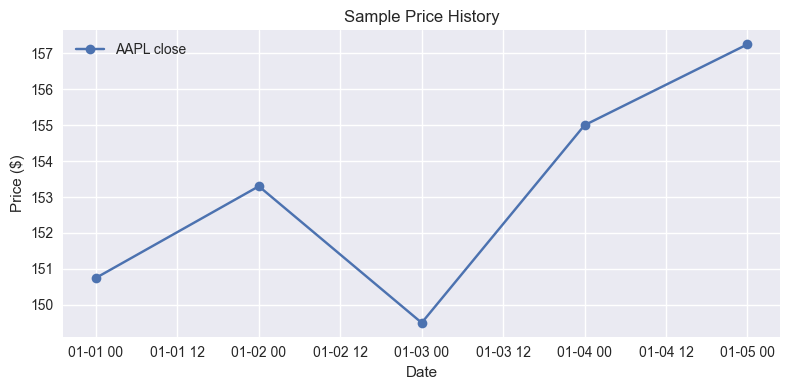

In [25]:
# Line chart of sample prices
dates = pd.date_range(start="2023-01-01", periods=5, freq="D")
prices = [150.75, 153.30, 149.50, 155.00, 157.25]

plt.figure(figsize=(8, 4))
plt.plot(dates, prices, marker="o", label="AAPL close")
plt.title("Sample Price History")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Visualizing Return Distributions
Histograms help inspect the distribution of returns for risk assessment.

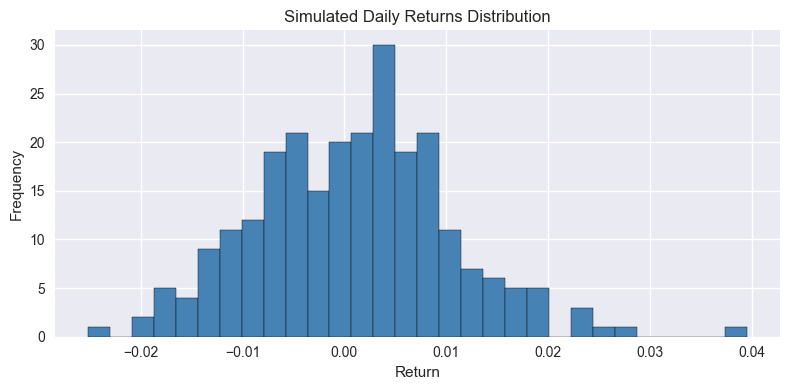

In [26]:
# Histogram of simulated daily returns
np.random.seed(42)
simulated_returns = np.random.normal(loc=0.001, scale=0.01, size=250)

plt.figure(figsize=(8, 4))
plt.hist(simulated_returns, bins=30, color="steelblue", edgecolor="black")
plt.title("Simulated Daily Returns Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()